<a href="https://colab.research.google.com/github/murokiruth/CreditRiskPrediction_MachineLearning/blob/main/ML_CreditRiskPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Risk Prediction — Machine Learning Project

**Course:** BCIS 466/566 — Machine Learning and Predictive Analytics  
**Dataset:** UCI Default of Credit Card Clients — 30,000 observations, 23 features  
**Models:** Logistic Regression, Random Forest (Base + Tuned)  
**Description:** Machine learning project predicting credit card default risk
using classification models on the UCI Credit Card Default dataset.  
**Source:** https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

**GitHub Link** https://github.com/murokiruth/CreditRiskPrediction_MachineLearning/tree/main

# Libraries


In [1]:

##importing libraries

#core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#pre-processing tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#evaluation tools
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay, f1_score, precision_score, recall_score

#plotting tools
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120




# Loading Dataset and Cleaning Data


In [2]:

#loading dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df = pd.read_excel(url, header=1)
print("Dataset Head: \n", df.head())
print("\nDataset Shape \n", df.shape)



Dataset Head: 
    ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1      20000    2          2         1   24      2      2     -1     -1   
1   2     120000    2          2         2   26     -1      2      0      0   
2   3      90000    2          2         2   34      0      0      0      0   
3   4      50000    2          2         1   37      0      0      0      0   
4   5      50000    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...          0          0          0         0       689         0   
1  ...       3272       3455       3261         0      1000      1000   
2  ...      14331      14948      15549      1518      1500      1000   
3  ...      28314      28959      29547      2000      2019      1200   
4  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default payment next month  
0       

In [3]:

##data cleaning

#dropping the ID column — it's just a row number, not a real feature
df.drop(columns=["ID"], inplace=True)

#renaming target column
df.rename(columns={"default payment next month": "default"}, inplace=True)

#checking for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values found!")

print("\nDataset Head: \n", df.head())
print("\nDataset Shape \n", df.shape)
print("\nDataset Columns:", df.columns.tolist())

#checking dataset basic info
print("\n=== Dataset Info ===")
df.info()



Missing values per column:
No missing values found!

Dataset Head: 
    LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0      20000    2          2         1   24      2      2     -1     -1   
1     120000    2          2         2   26     -1      2      0      0   
2      90000    2          2         2   34      0      0      0      0   
3      50000    2          2         1   37      0      0      0      0   
4      50000    1          2         1   57     -1      0     -1      0   

   PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0     -2  ...          0          0          0         0       689         0   
1      0  ...       3272       3455       3261         0      1000      1000   
2      0  ...      14331      14948      15549      1518      1500      1000   
3      0  ...      28314      28959      29547      2000      2019      1200   
4      0  ...      20940      19146      19131      2000     36681     10000   


# Exploratory Data Analysis Section


In [4]:
print("=== Dataset Summary Statistics ===")
df.describe().round(2)

=== Dataset Summary Statistics ===


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,-0.27,...,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,1.13,...,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,-2.00,...,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,-1.00,...,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,0.00,...,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,0.00,...,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,8.00,...,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00



=== Class Distribution Bar Plot ===
Not defaulted (0): 23364 (77.9%)
Defaulted    (1): 6636 (22.1%)


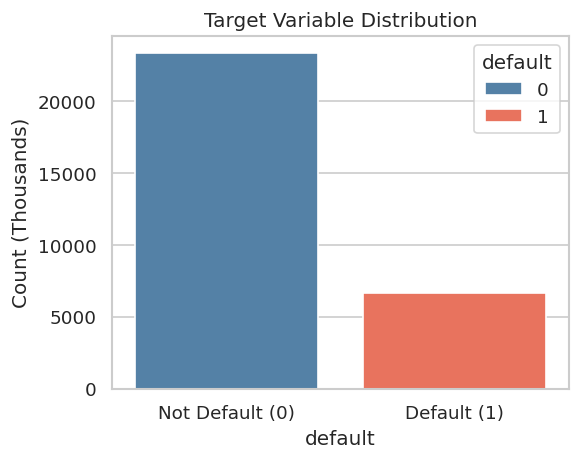

In [5]:
##EDA

#### Class Distribution Bar Plot ####
print("\n=== Class Distribution Bar Plot ===")
counts = df["default"].value_counts()
pct = df["default"].value_counts(normalize=True) * 100

print(f"Not defaulted (0): {counts[0]} ({pct[0]:.1f}%)")
print(f"Defaulted    (1): {counts[1]} ({pct[1]:.1f}%)")

plt.figure(figsize=(5, 4))
sns.countplot(x="default", hue="default", data=df, palette=["steelblue", "tomato"])
plt.title("Target Variable Distribution")
plt.xticks([0, 1], ["Not Default (0)", "Default (1)"])
plt.ylabel("Count (Thousands)")
plt.tight_layout()
plt.show()


**key finding:** The dataset has a significant class imbalance, with 77.9% of customers in the "Not Default" category and 22.1% in the "Default" category.


=== Correlation Heatmap ===


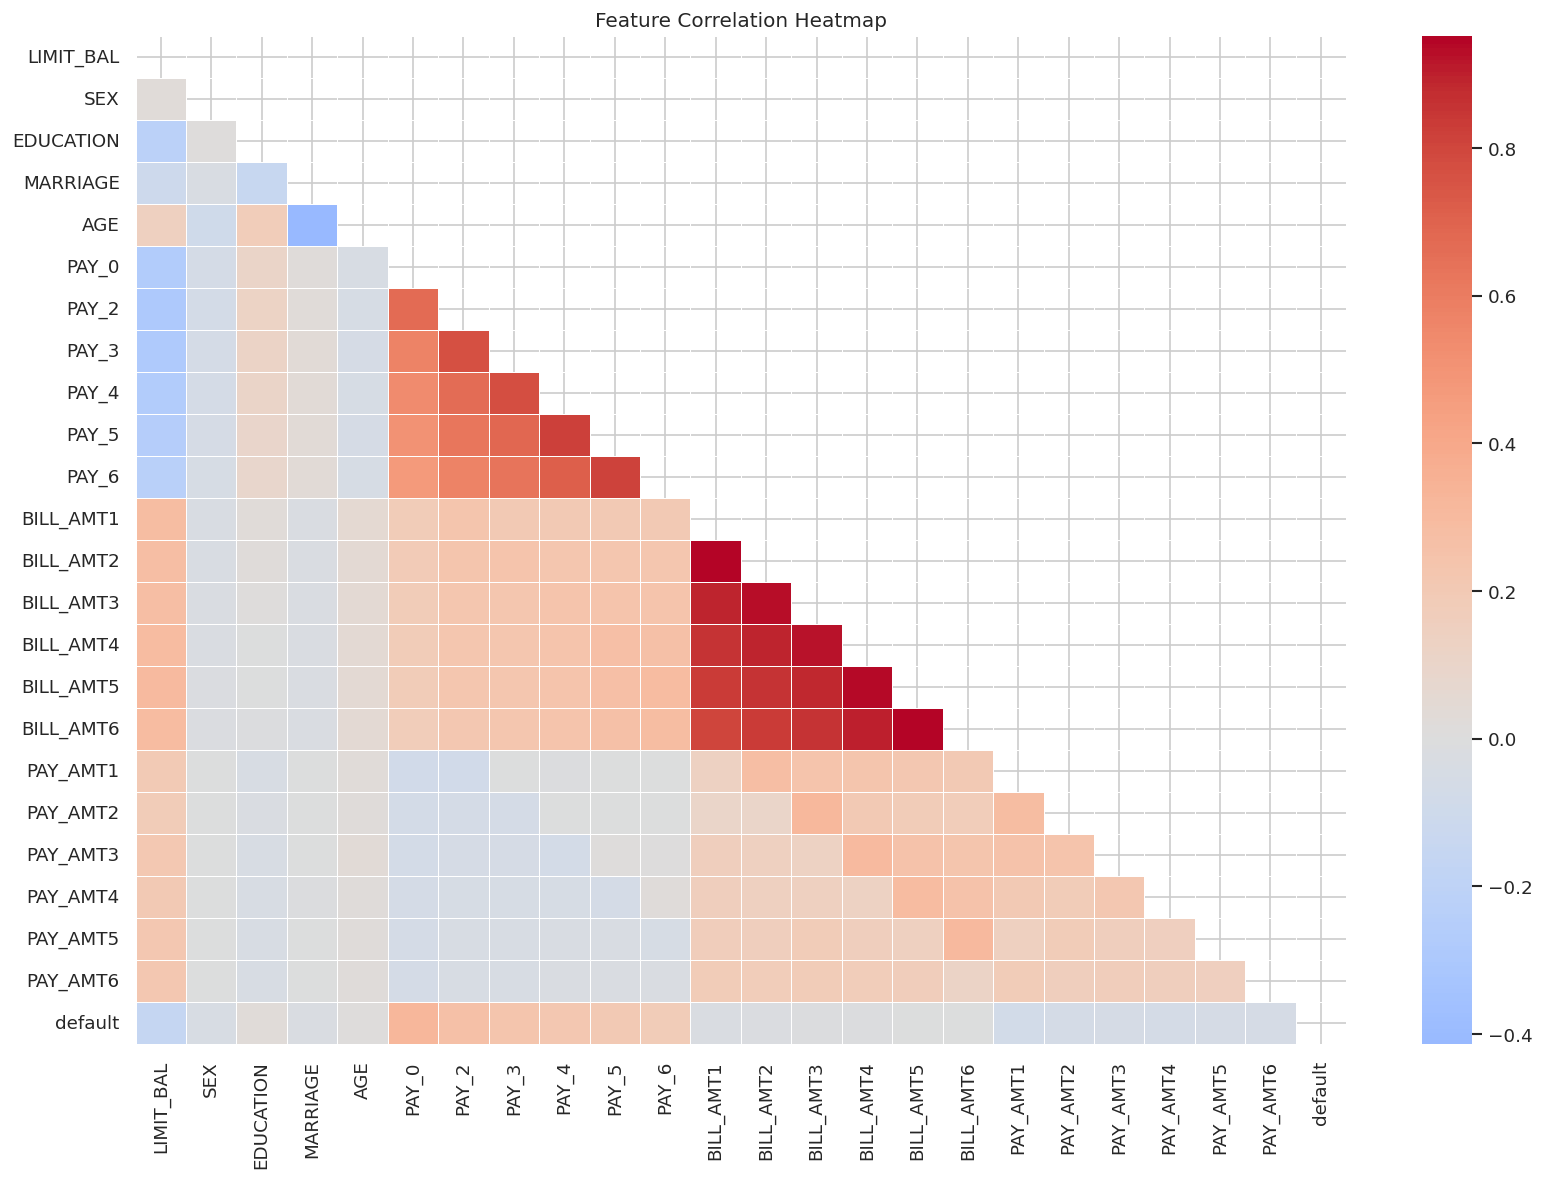

In [6]:
#### Correlation Plot ####
print("\n=== Correlation Heatmap ===")
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            annot=False, linewidths=0.4)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


**key finding:** BILL_AMT columns are highly correlated (multicollinear).
PAY_0 and LIMIT_BAL stand out as the most independent and reliable risk indicators.


=== Age Distribution Histogram with KDE (Kernel Density Estimate)===


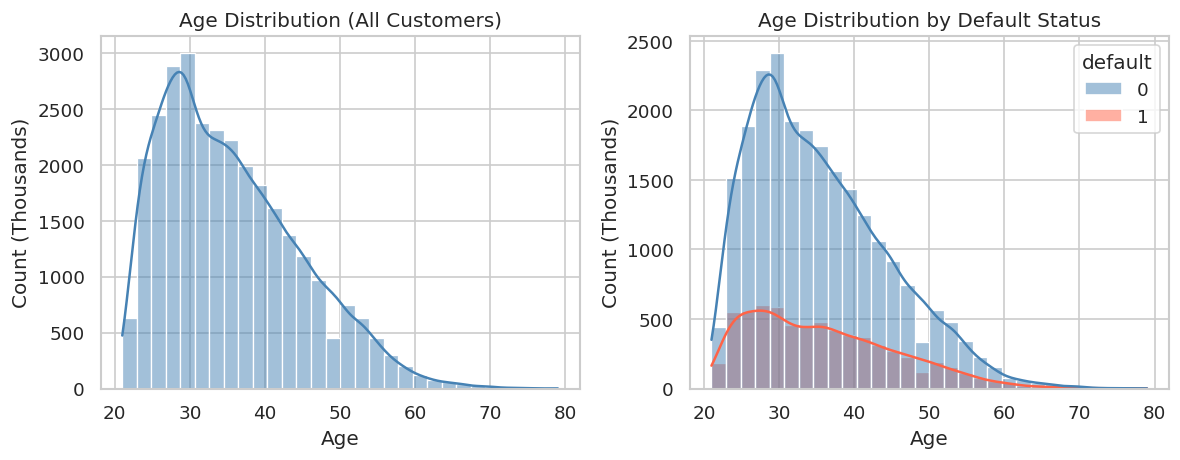

Age distribution summary stats: 
            count  mean  std   min   25%   50%   75%   max
default                                                  
0        23364.0  35.4  9.1  21.0  28.0  34.0  41.0  79.0
1         6636.0  35.7  9.7  21.0  28.0  34.0  42.0  75.0


In [7]:
#### Age Distribution Plot ####
print("\n=== Age Distribution Histogram with KDE (Kernel Density Estimate)===")

plt.figure(figsize=(10, 4))

#left plot: overall age distribution
plt.subplot(1, 2, 1)
sns.histplot(df["AGE"], bins=30, color="steelblue", kde=True)
plt.title("Age Distribution (All Customers)")
plt.xlabel("Age")
plt.ylabel("Count (Thousands)")

#right plot: age distribution split by default status
plt.subplot(1, 2, 2)
sns.histplot(data=df, x="AGE", hue="default", bins=30,
             palette=["steelblue", "tomato"], kde=True, legend=True)
plt.title("Age Distribution by Default Status")
plt.xlabel("Age")
plt.ylabel("Count (Thousands)")

plt.tight_layout()
plt.show()

#summary stats
print("Age distribution summary stats: \n", df.groupby("default")["AGE"].describe().round(1))



**key finding:** Age distributions for both groups are statistically similar with a peak around 30 years old, age alone is a weak predictor.


=== Credit Limit Box Plot vs Default Density Plot ===


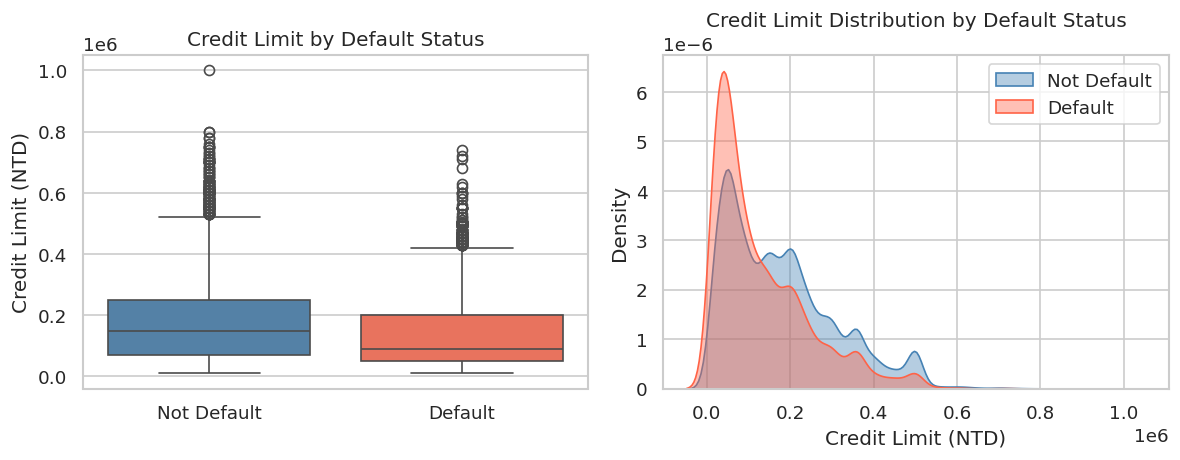

credit limit Vs default status summary stats 
            count      mean       std      min      25%       50%       75%  \
default                                                                      
0        23364.0  178100.0  131628.0  10000.0  70000.0  150000.0  250000.0   
1         6636.0  130110.0  115379.0  10000.0  50000.0   90000.0  200000.0   

               max  
default             
0        1000000.0  
1         740000.0  


In [8]:
#### Credit Limit vs Default Plots ####
print("\n=== Credit Limit Box Plot vs Default Density Plot ===")

plt.figure(figsize=(10, 4))

#left plot: boxplot comparing credit limit by default status
plt.subplot(1, 2, 1)
sns.boxplot(x="default", y="LIMIT_BAL", data=df,
            palette=["steelblue", "tomato"], hue="default", legend=False)
plt.title("Credit Limit by Default Status")
plt.xticks([0, 1], ["Not Default", "Default"])
plt.xlabel("")
plt.ylabel("Credit Limit (NTD)")

#right plot: distribution of credit limit by default status
plt.subplot(1, 2, 2)
sns.kdeplot(data=df[df["default"] == 0], x="LIMIT_BAL",
            label="Not Default", color="steelblue", fill=True, alpha=0.4)
sns.kdeplot(data=df[df["default"] == 1], x="LIMIT_BAL",
            label="Default", color="tomato", fill=True, alpha=0.4)
plt.title("Credit Limit Distribution by Default Status")
plt.xlabel("Credit Limit (NTD)")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

#summary stats
print("credit limit Vs default status summary stats \n", df.groupby("default")["LIMIT_BAL"].describe().round(0))


**key finding:** Defaulters have a lower median credit limit and a higher density concentration at lower credit limits compared to non-defaulters.


=== Payment Status Clustered Bar Plots===


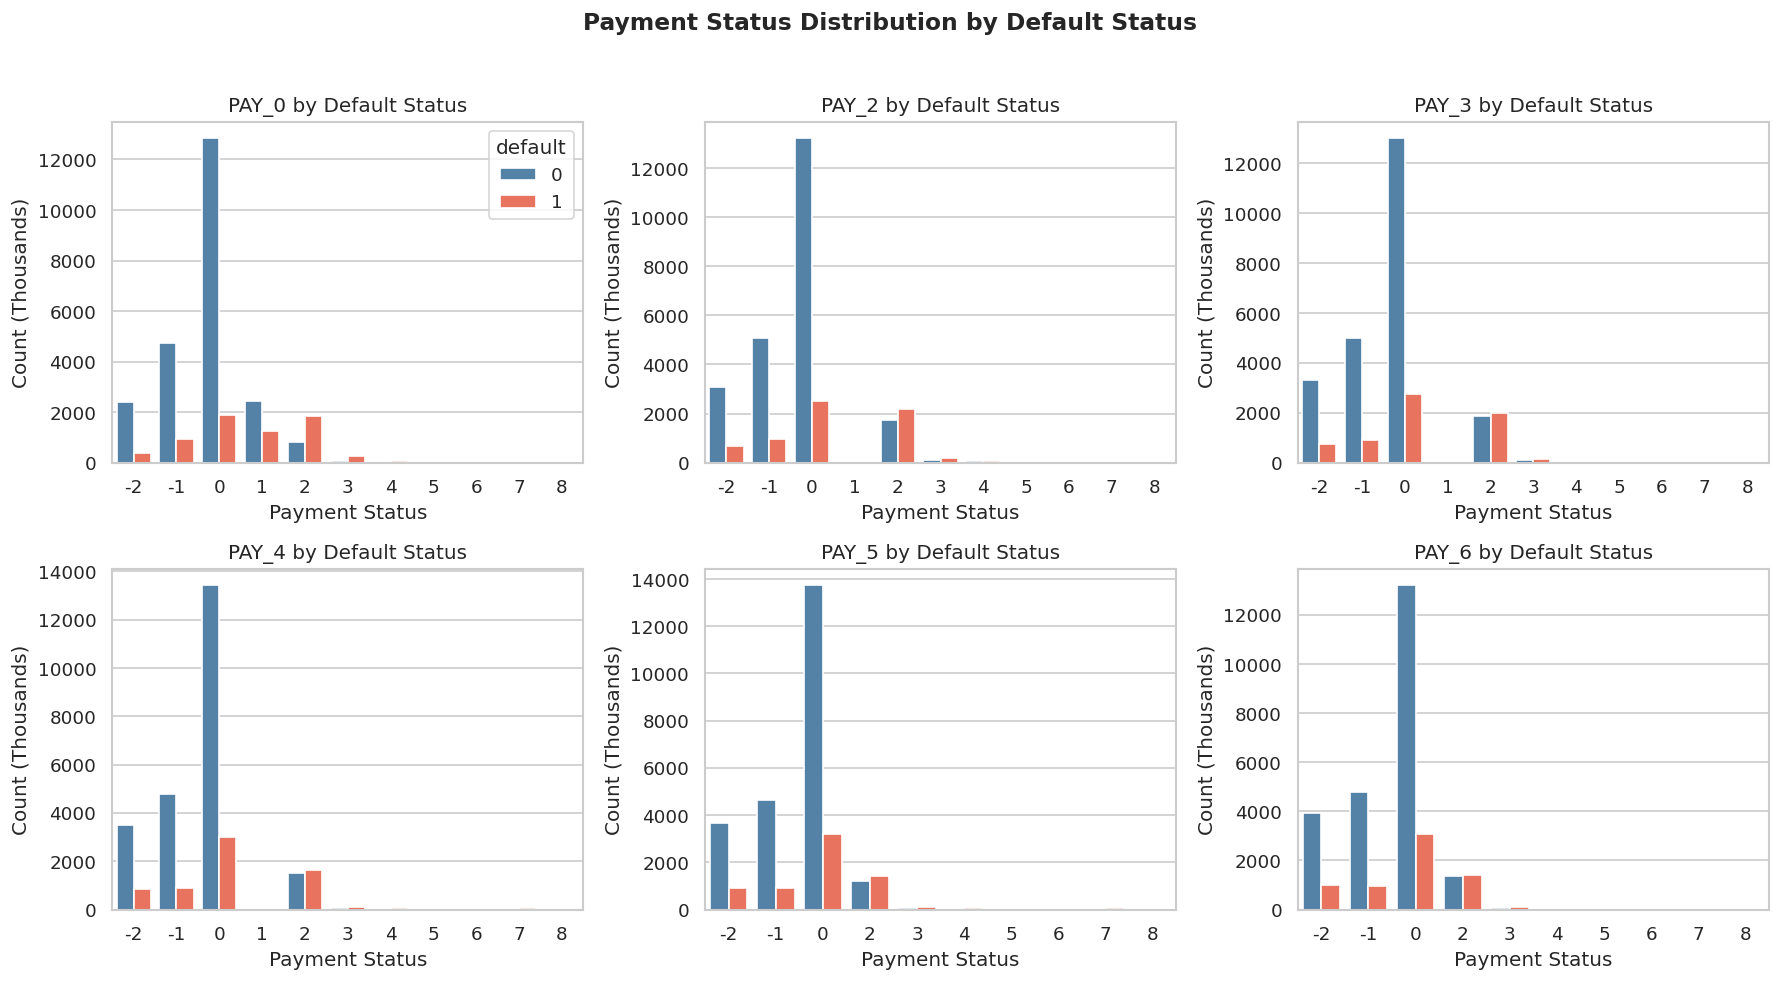

Default rate by PAY_0 (most recent payment status):
PAY_0
-2    0.132
-1    0.168
 0    0.128
 1    0.339
 2    0.691
 3    0.758
 4    0.684
 5    0.500
 6    0.545
 7    0.778
 8    0.579


In [9]:
#### Payment Status Distribution ####
print("\n=== Payment Status Clustered Bar Plots===")
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(pay_cols):
    sns.countplot(x=col, hue="default", data=df,
                  palette=["steelblue", "tomato"],
                  ax=axes[i], legend=(i == 0))
    axes[i].set_title(f"{col} by Default Status")
    axes[i].set_xlabel("Payment Status")
    axes[i].set_ylabel("Count (Thousands)")

plt.suptitle("Payment Status Distribution by Default Status",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#summary of default rate by PAY_0 status (most recent month, strongest signal)
print("Default rate by PAY_0 (most recent payment status):")
print(df.groupby("PAY_0")["default"].mean().round(3).to_string())

**key finding:** The probability of default jumps sharply from 12.8% to over 69% once a customer reaches a two-month delay making PAY_0 a strong predictor.

# Pre-Processing Section


In [10]:

#checking for undocumented/unexpected category values before cleaning
print("EDUCATION values:", sorted(df["EDUCATION"].unique()))
print("MARRIAGE values: ", sorted(df["MARRIAGE"].unique()))
print("SEX values:      ", sorted(df["SEX"].unique()))

print("\nEDUCATION value counts:")
print(df["EDUCATION"].value_counts().sort_index())

print("\nMARRIAGE value counts:")
print(df["MARRIAGE"].value_counts().sort_index())


EDUCATION values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
MARRIAGE values:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
SEX values:       [np.int64(1), np.int64(2)]

EDUCATION value counts:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE value counts:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [11]:

#cleaning up unknown category values
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

#verifying cleanup
print("EDUCATION values after cleaning:", sorted(df["EDUCATION"].unique()))
print("MARRIAGE values after cleaning: ", sorted(df["MARRIAGE"].unique()))

print("\nEDUCATION value counts after cleaning:")
print(df["EDUCATION"].value_counts().sort_index())

print("\nMARRIAGE value counts after cleaning:")
print(df["MARRIAGE"].value_counts().sort_index())


EDUCATION values after cleaning: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE values after cleaning:  [np.int64(1), np.int64(2), np.int64(3)]

EDUCATION value counts after cleaning:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE value counts after cleaning:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


In [12]:

#splitting
X = df.drop(columns=["default"])
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("== splitting 80/20 ==")
print(f"Training set:   {X_train.shape}")
print(f"Test set:       {X_test.shape}")
print(f"Train default rate: {y_train.mean():.3f}")
print(f"Test default rate:  {y_test.mean():.3f}")


== splitting 80/20 ==
Training set:   (24000, 23)
Test set:       (6000, 23)
Train default rate: 0.221
Test default rate:  0.221


# Modeling

In [13]:

#columns
scale_cols = ["LIMIT_BAL", "AGE", "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
              "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
              "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
              "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

passthrough_cols = ["SEX", "EDUCATION", "MARRIAGE",
                    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]


In [14]:

#preprocessor (scaling only, inside pipeline)
preprocessor = ColumnTransformer(transformers=[
    ("scale", StandardScaler(), scale_cols),
    ("passthrough", "passthrough", passthrough_cols)
])


In [15]:

#pipeline implementation
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        class_weight="balanced"
    ))
])




In [16]:

#training
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

lr_preds = lr_pipeline.predict(X_test)
rf_preds = rf_pipeline.predict(X_test)


## Evaluation

In [17]:

print("=== Accuracy Reports ===")

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.4f}")


=== Accuracy Reports ===
Logistic Regression Accuracy: 0.6797
Random Forest Accuracy: 0.7883


**key finding:** Accuracy alone can be misleading because of the class imbalance evident in the target variable distribution chart.

In [18]:

print("=== Classification Reports ===")

print("\n==Logistic Regression Results ===")
print(classification_report(y_test, lr_preds, target_names=["Not Default", "Default"]))
print("\n=== Random Forest Results ===")
print(classification_report(y_test, rf_preds, target_names=["Not Default", "Default"]))


=== Classification Reports ===

==Logistic Regression Results ===
              precision    recall  f1-score   support

 Not Default       0.87      0.70      0.77      4673
     Default       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000


=== Random Forest Results ===
              precision    recall  f1-score   support

 Not Default       0.87      0.85      0.86      4673
     Default       0.52      0.56      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.71      0.70      6000
weighted avg       0.79      0.79      0.79      6000



**key finding:** The Random Forest model has a better F1 score(0.54 vs 0.46), precision (0.52 vs 0.37).

In [19]:

print("\n=== ROC-AUC Scores ===")
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")
print(f"Random Forest ROC-AUC:       {roc_auc_score(y_test, rf_proba):.4f}")



=== ROC-AUC Scores ===
Logistic Regression ROC-AUC: 0.7084
Random Forest ROC-AUC:       0.7733


=== Confusion Matrices Plots===


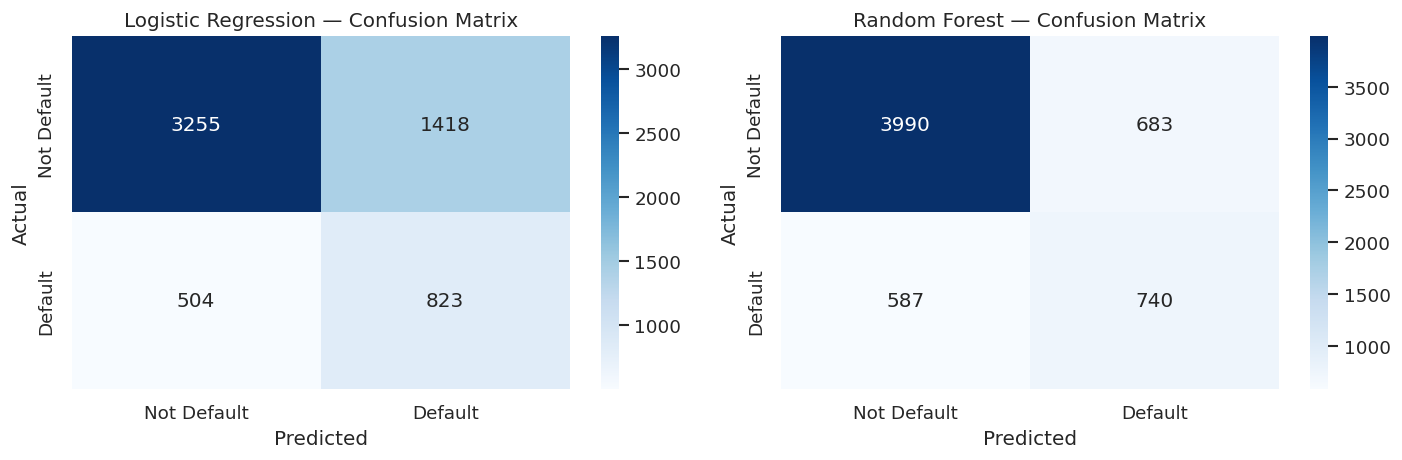

In [20]:

print("=== Confusion Matrices Plots===")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(axes,
                             [lr_preds, rf_preds],
                             ["Logistic Regression", "Random Forest"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Default", "Default"],
                yticklabels=["Not Default", "Default"])
    ax.set_title(f"{title} — Confusion Matrix")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()


**key finding:** Logistic Regression is more aggressive at capturing the total number of actual defaults.

## Hyperparameter tuning

In [21]:

print("=== Hyperparameter tuning ===")

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 20]
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)
print(f"Best Cross-Validated F1: {grid.best_score_:.4f}")

#evaluating tuned model
best_rf = grid.best_estimator_
best_rf_preds = best_rf.predict(X_test)
best_rf_proba = best_rf.predict_proba(X_test)[:, 1]

print("\n=== Tuned Random Forest ===")
print(classification_report(y_test, best_rf_preds,
                            target_names=["Not Default", "Default"]))
print(f"ROC-AUC: {roc_auc_score(y_test, best_rf_proba):.4f}")


=== Hyperparameter tuning ===
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best Parameters: {'classifier__max_depth': 10, 'classifier__n_estimators': 200}
Best Cross-Validated F1: 0.5407

=== Tuned Random Forest ===
              precision    recall  f1-score   support

 Not Default       0.87      0.85      0.86      4673
     Default       0.52      0.56      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.71      0.70      6000
weighted avg       0.79      0.79      0.79      6000

ROC-AUC: 0.7737


**key finding:** Best parameters are max_depth=10, n_estimators=200. Increasing the number of trees to 200 while keeping them shallow (depth=10) produces the best balance between learning and generalization

## Final Model Evaluation

=== Tuned Random Forest Confusion Matrix ===


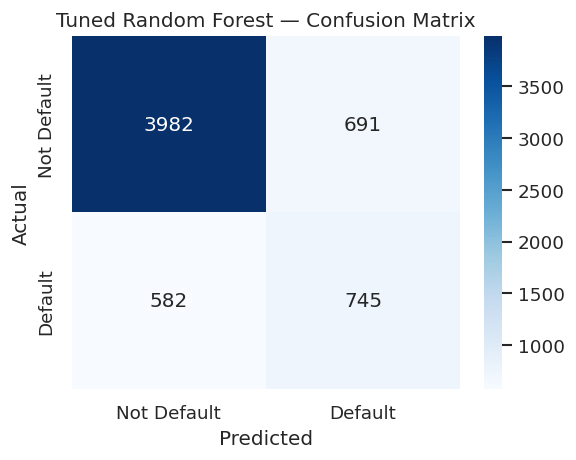

In [22]:

#confusion matrix for tuned random forest
print("=== Tuned Random Forest Confusion Matrix ===")
fig, ax = plt.subplots(figsize=(5, 4))

cm = confusion_matrix(y_test, best_rf_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Not Default", "Default"],
            yticklabels=["Not Default", "Default"])

ax.set_title("Tuned Random Forest — Confusion Matrix")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()


**Key Finding:** This Tuned Random Forest model correctly identified 745 defaults (vs 740 base)
and 3,982 non-defaults (vs 3,990 base). It shows marginal improvement with consistent performance.

In [23]:

#classification report for tuned random forest
print("=== Tuned Random Forest Classification Report ===")
print(classification_report(y_test, best_rf_preds, target_names=["Not Default", "Default"]))

=== Tuned Random Forest Classification Report ===
              precision    recall  f1-score   support

 Not Default       0.87      0.85      0.86      4673
     Default       0.52      0.56      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.71      0.70      6000
weighted avg       0.79      0.79      0.79      6000



=== Tuned Random Forest ROC Curves Plot ===


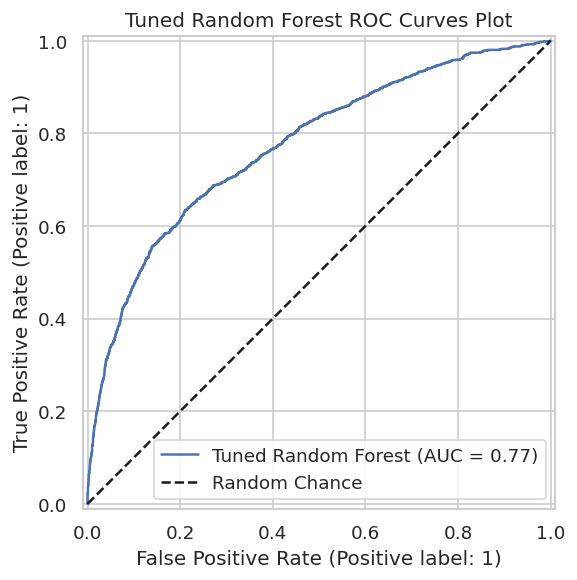

In [24]:
#ROC curve plot for tuned random forest

print("=== Tuned Random Forest ROC Curves Plot ===")
fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(y_test, best_rf_proba, name="Tuned Random Forest", ax=ax)


ax.plot([0, 1], [0, 1], "k--", label="Random Chance")
ax.set_title("Tuned Random Forest ROC Curves Plot")
ax.legend()
plt.tight_layout()
plt.show()


## Model Comparison & Visualization

=== ROC Curves Plot ===


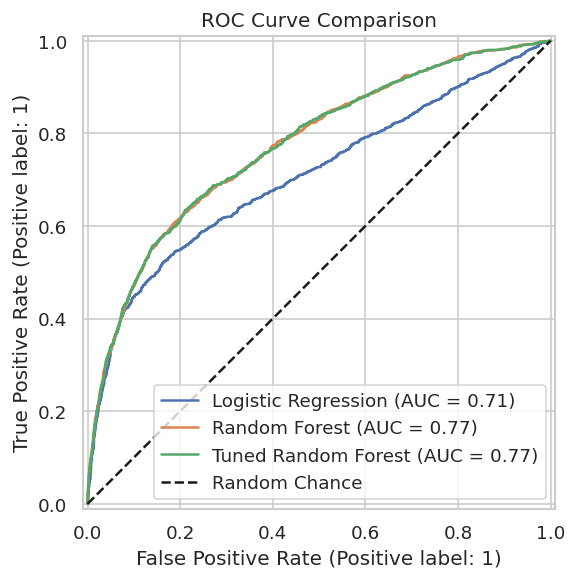

In [25]:

print("=== ROC Curves Plot ===")
fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(y_test, lr_proba, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_proba, name="Random Forest", ax=ax)
RocCurveDisplay.from_predictions(y_test, best_rf_proba, name="Tuned Random Forest", ax=ax)


ax.plot([0, 1], [0, 1], "k--", label="Random Chance")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.tight_layout()
plt.show()


**key finding:** Both Random Forest Models outperform the Logistic Regression model (AUC 0.77 vs 0.71).

=== Feature Importance ===


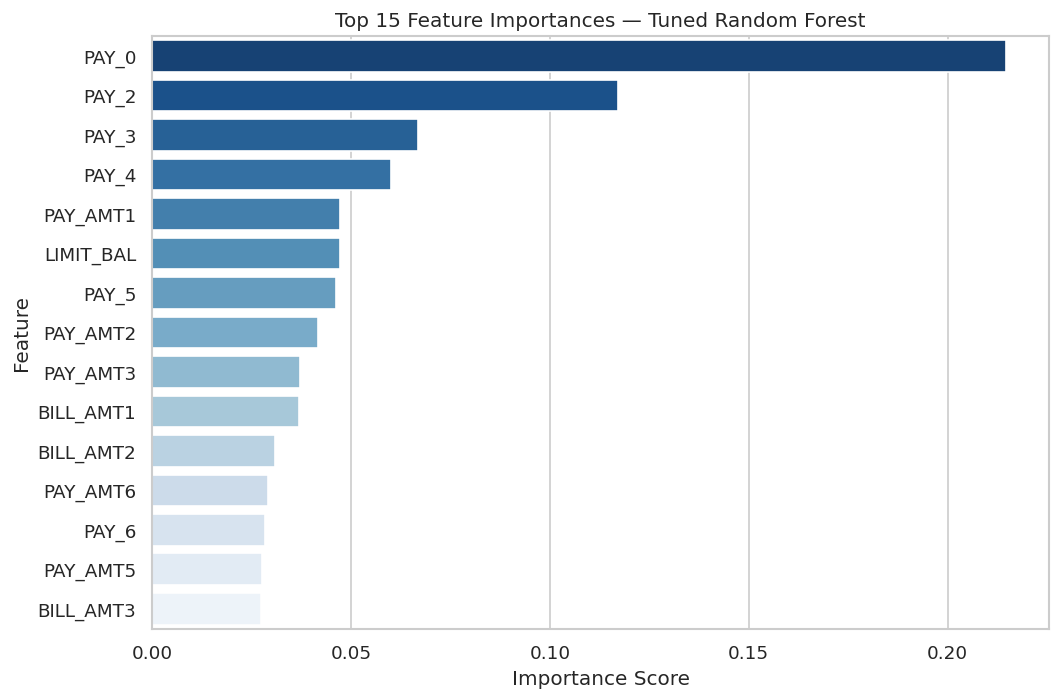

  Feature  Importance
    PAY_0    0.214713
    PAY_2    0.117225
    PAY_3    0.066807
    PAY_4    0.059982
 PAY_AMT1    0.047145
LIMIT_BAL    0.047098
    PAY_5    0.046167
 PAY_AMT2    0.041771
 PAY_AMT3    0.037114
BILL_AMT1    0.036920
BILL_AMT2    0.030760
 PAY_AMT6    0.029121
    PAY_6    0.028347
 PAY_AMT5    0.027629
BILL_AMT3    0.027376


In [26]:

print("=== Feature Importance ===")

#extracting feature names from the pipeline
feature_names = (scale_cols + passthrough_cols)

#extracting importances from the tuned RF classifier
importances = best_rf.named_steps["classifier"].feature_importances_
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(15)

#plotting
plt.figure(figsize=(9, 6))
sns.barplot(x="Importance", y="Feature", data=feat_imp,
            palette="Blues_r", hue="Feature", legend=False)
plt.title("Top 15 Feature Importances — Tuned Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print(feat_imp.to_string(index=False))


**key finding:** The most recent payment status (PAY_0) is the most important feature. Demographic features (AGE, SEX, EDUCATION) do not appear in top 15 features.

In [27]:

print("=== Model Comparison Summary Table ===")

#side by side table for all 3 models: accuracy, precision, recall, f1, roc-auc

models = ["Logistic Regression", "Random Forest (Base)", "Random Forest (Tuned)"]
preds_list = [lr_preds, rf_preds, best_rf_preds]
proba_list = [lr_proba, rf_proba, best_rf_proba]

summary = []
for name, preds, proba in zip(models, preds_list, proba_list):
    summary.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds), 4),
        "Recall":    round(recall_score(y_test, preds), 4),
        "F1 Score":  round(f1_score(y_test, preds), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, proba), 4)
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))


=== Model Comparison Summary Table ===
                Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
  Logistic Regression    0.6797     0.3672  0.6202    0.4613   0.7084
 Random Forest (Base)    0.7883     0.5200  0.5576    0.5382   0.7733
Random Forest (Tuned)    0.7878     0.5188  0.5614    0.5393   0.7737


**Key Finding:** The Tuned Random Forest is the best model — highest F1 (0.54) and ROC-AUC (0.77) with the best balance of precision and recall.